# 04. 化学量論的 vs 触媒的 — sRNA の作用機構が応答形状を決める

02/03 の共分解は **化学量論的 (stoichiometric)**: sRNA も mRNA と一緒に消える。

$$ m + s \to \varnothing \qquad \text{sRNA は 1:1 で消費} \;\Rightarrow\; \text{鋭い閾値} $$

これを **触媒的 (catalytic)** に変える: sRNA は mRNA を壊すが自分は再利用される（酵素的）。

$$ m + s \to s \qquad \text{sRNA は残る} \;\Rightarrow\; \text{なだらかな滴定} $$

触媒では定常 sRNA が $s = a_s/b_s$ と mRNA から独立に決まるので
$$ \langle m\rangle = \frac{a_m}{b_m + k_{cat}\,s} = \frac{a_m}{b_m + k_{cat}\,a_s/b_s} $$
という双曲線（Hill 係数 1、Michaelis-Menten 的）になり、閾値スイッチが消える。

**含意**: 同じ「sRNA が mRNA を抑える」でも、消費されるか触媒かで
**デジタルなスイッチ**か**アナログな可変抵抗**かが決まる。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

M, S = Species('m'), Species('s')
A_M, B_M, B_S = 10.0, 1.0, 1.0
K_STO, K_CAT = 100.0, 0.1   # 化学量論(強い) / 触媒(半減点を a_s=10 に合わせた)

def build(a_s, mode):
    mdl = NetworkModel()
    rules = [ReactionRule([], [M], A_M), ReactionRule([], [S], a_s),
             ReactionRule([M], [], B_M), ReactionRule([S], [], B_S)]
    rules.append(ReactionRule([M, S], [], K_STO) if mode == 'stoichiometric'
                 else ReactionRule([M, S], [S], K_CAT))
    for rr in rules:
        mdl.add_reaction_rule(rr)
    return mdl

def ode_m(a_s, mode):
    r = run_simulation(150.0, y0={'m':0,'s':0}, model=build(a_s, mode),
                       solver='ode', ndiv=1500, species_list=['m','s'])
    return r.as_array()[-1][1]

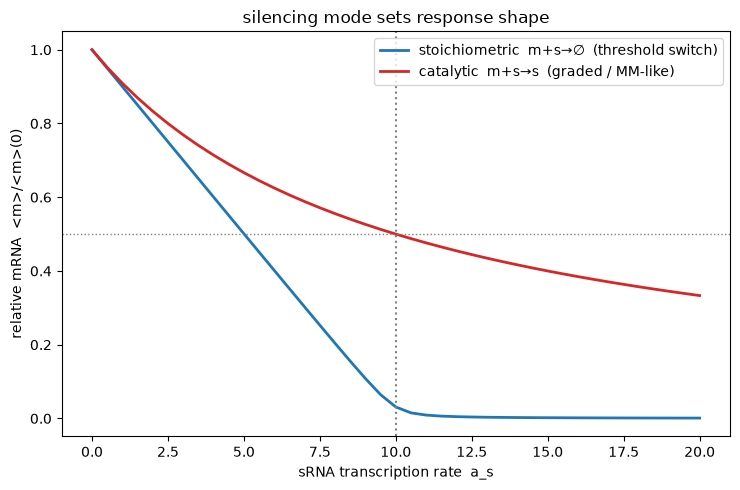

In [2]:
a_grid = np.linspace(0, 20, 41)
sto = np.array([ode_m(a, 'stoichiometric') for a in a_grid])
cat = np.array([ode_m(a, 'catalytic') for a in a_grid])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(a_grid, sto/A_M, '-', color='C0', lw=2, label='stoichiometric  m+s→∅  (threshold switch)')
ax.plot(a_grid, cat/A_M, '-', color='C3', lw=2, label='catalytic  m+s→s  (graded / MM-like)')
ax.axvline(A_M, ls=':', c='gray'); ax.axhline(0.5, ls=':', c='gray', lw=1)
ax.set_xlabel('sRNA transcription rate  a_s'); ax.set_ylabel('relative mRNA  <m>/<m>(0)')
ax.set_title('silencing mode sets response shape'); ax.legend()
plt.tight_layout(); plt.show()

## 読み取り

- **化学量論的（青）**: sRNA が 1:1 で mRNA を滴定 → $a_s < a_m$ で線形に減り $a_s = a_m$ で折れて底打ち。**ほぼ全か無のスイッチ**。標的を確実に切りたい制御に向く。
- **触媒的（赤）**: sRNA が酵素的に働き mRNA 寿命を縮める → 双曲線でなだらかに下がり、**ゼロにはならない**。sRNA 量で連続的にダイヤルできる**可変抵抗**。

実際の細菌 sRNA には両タイプがある（多くの Hfq 依存 sRNA は共分解＝化学量論寄り、一部は触媒的に複数標的を回す）。この形状の違いは、[[bio-a_hfq-phylogenetics]] で見る Hfq/sRNA の配列・複合体様式の多様性が、**制御のデジタル/アナログ性**として表現型に効く、という接点になる。

## 練習問題

1. 触媒 $k_{cat}$ を変え、双曲線の半減点 $a_s^{1/2} = b_m b_s/k_{cat}$ が理論どおり動くか確認。
2. Gillespie で両モードのノイズを比べる。スイッチ（化学量論）の方が閾値で本当にノイジー?
3. 化学量論と触媒を**混在**させ（`m+s→∅` と `m+s→s` を両方、比率を振る）、応答が threshold と graded の中間になる様子を見る。